In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
print("imports done")

imports done


In [2]:
class CFG:
    data_dir   = Path("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1")
    img_dir    = data_dir / "images"
    train_csv  = data_dir / "train.csv"
    test_csv   = data_dir / "test.csv"
    sub_csv    = data_dir / "sample_submission.csv"
    output_dir = Path("/kaggle/working/")

    seed         = 42
    img_size     = 320
    batch_size   = 32
    num_workers  = 2
    epochs       = 10
    lr           = 2e-4
    weight_decay = 1e-4
    n_folds      = 5
    train_fold   = 0

    model_name   = "efficientnet_b3"
    num_classes   = 20

    w_tp = 1
    w_fp = -1
    w_fn = -5

    device = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_NAMES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass", "Nodule",
    "Pleural_Thickening", "Pneumonia", "Pneumothorax", "Pneumoperitoneum",
    "Pneumomediastinum", "Subcutaneous Emphysema", "Tortuous Aorta",
    "Calcification of the Aorta", "No Finding"
]

NO_FINDING_IDX = CLASS_NAMES.index("No Finding")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)
print(f"device: {CFG.device}")
print(f"model: {CFG.model_name}, img_size: {CFG.img_size}, batch: {CFG.batch_size}, epochs: {CFG.epochs}")

device: cuda
model: efficientnet_b3, img_size: 320, batch: 32, epochs: 10


In [3]:
train_df = pd.read_csv(CFG.train_csv)
test_df  = pd.read_csv(CFG.test_csv)

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"\ncolumns: {list(train_df.columns)}")

missing = train_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f"missing values:\n{missing}")
else:
    print("no missing values")

print("\nfirst 5 rows:")
train_df.head()

train shape: (51043, 21)
test shape: (17015, 1)

columns: ['id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']
no missing values

first 5 rows:


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9cd3df7acfbf4bb8a00466801469b08b.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


class distribution:
  No Finding                           34079  (66.8%)
  Infiltration                          5206  (10.2%)
  Atelectasis                           2351  (4.6%)
  Effusion                              2156  (4.2%)
  Nodule                                1527  (3.0%)
  Mass                                  1249  (2.4%)
  Pneumothorax                          1114  (2.2%)
  Consolidation                          651  (1.3%)
  Pleural_Thickening                     608  (1.2%)
  Cardiomegaly                           600  (1.2%)
  Fibrosis                               389  (0.8%)
  Edema                                  326  (0.6%)
  Tortuous Aorta                         254  (0.5%)
  Emphysema                              172  (0.3%)
  Pneumonia                              160  (0.3%)
  Calcification of the Aorta              91  (0.2%)
  Pneumoperitoneum                        44  (0.1%)
  Hernia                                  37  (0.1%)
  Subcutaneous Emphysema

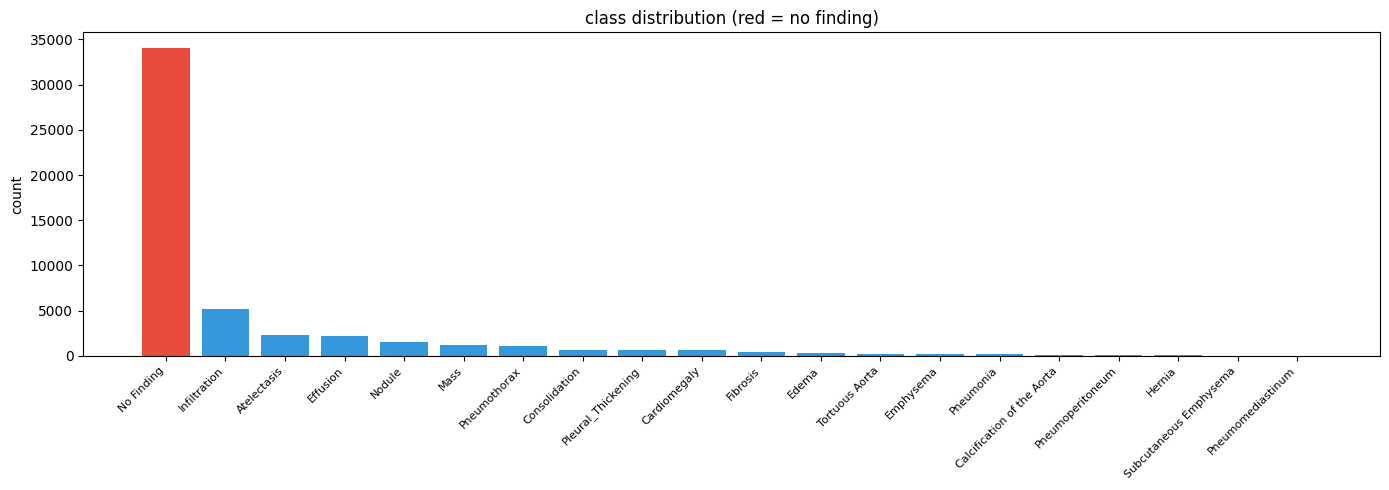


imbalance ratio: 6815.8x


In [4]:
train_df["_label"] = train_df[CLASS_NAMES].values.argmax(axis=1)

dist = Counter(train_df["_label"].values)
class_cnts = [(CLASS_NAMES[i], dist.get(i, 0)) for i in range(CFG.num_classes)]
class_cnts.sort(key=lambda x: -x[1])

print("class distribution:")
for name, cnt in class_cnts:
    print(f"  {name:<35} {cnt:>6}  ({cnt/len(train_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 5))
names  = [n for n, _ in class_cnts]
counts = [c for _, c in class_cnts]
colors = ["#e74c3c" if n == "No Finding" else "#3498db" for n in names]
ax.bar(range(len(names)), counts, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("count")
ax.set_title("class distribution (red = no finding)")
plt.tight_layout()
plt.savefig(CFG.output_dir / "class_dist.png", dpi=100)
plt.show()

print(f"\nimbalance ratio: {max(counts)/min(counts):.1f}x")

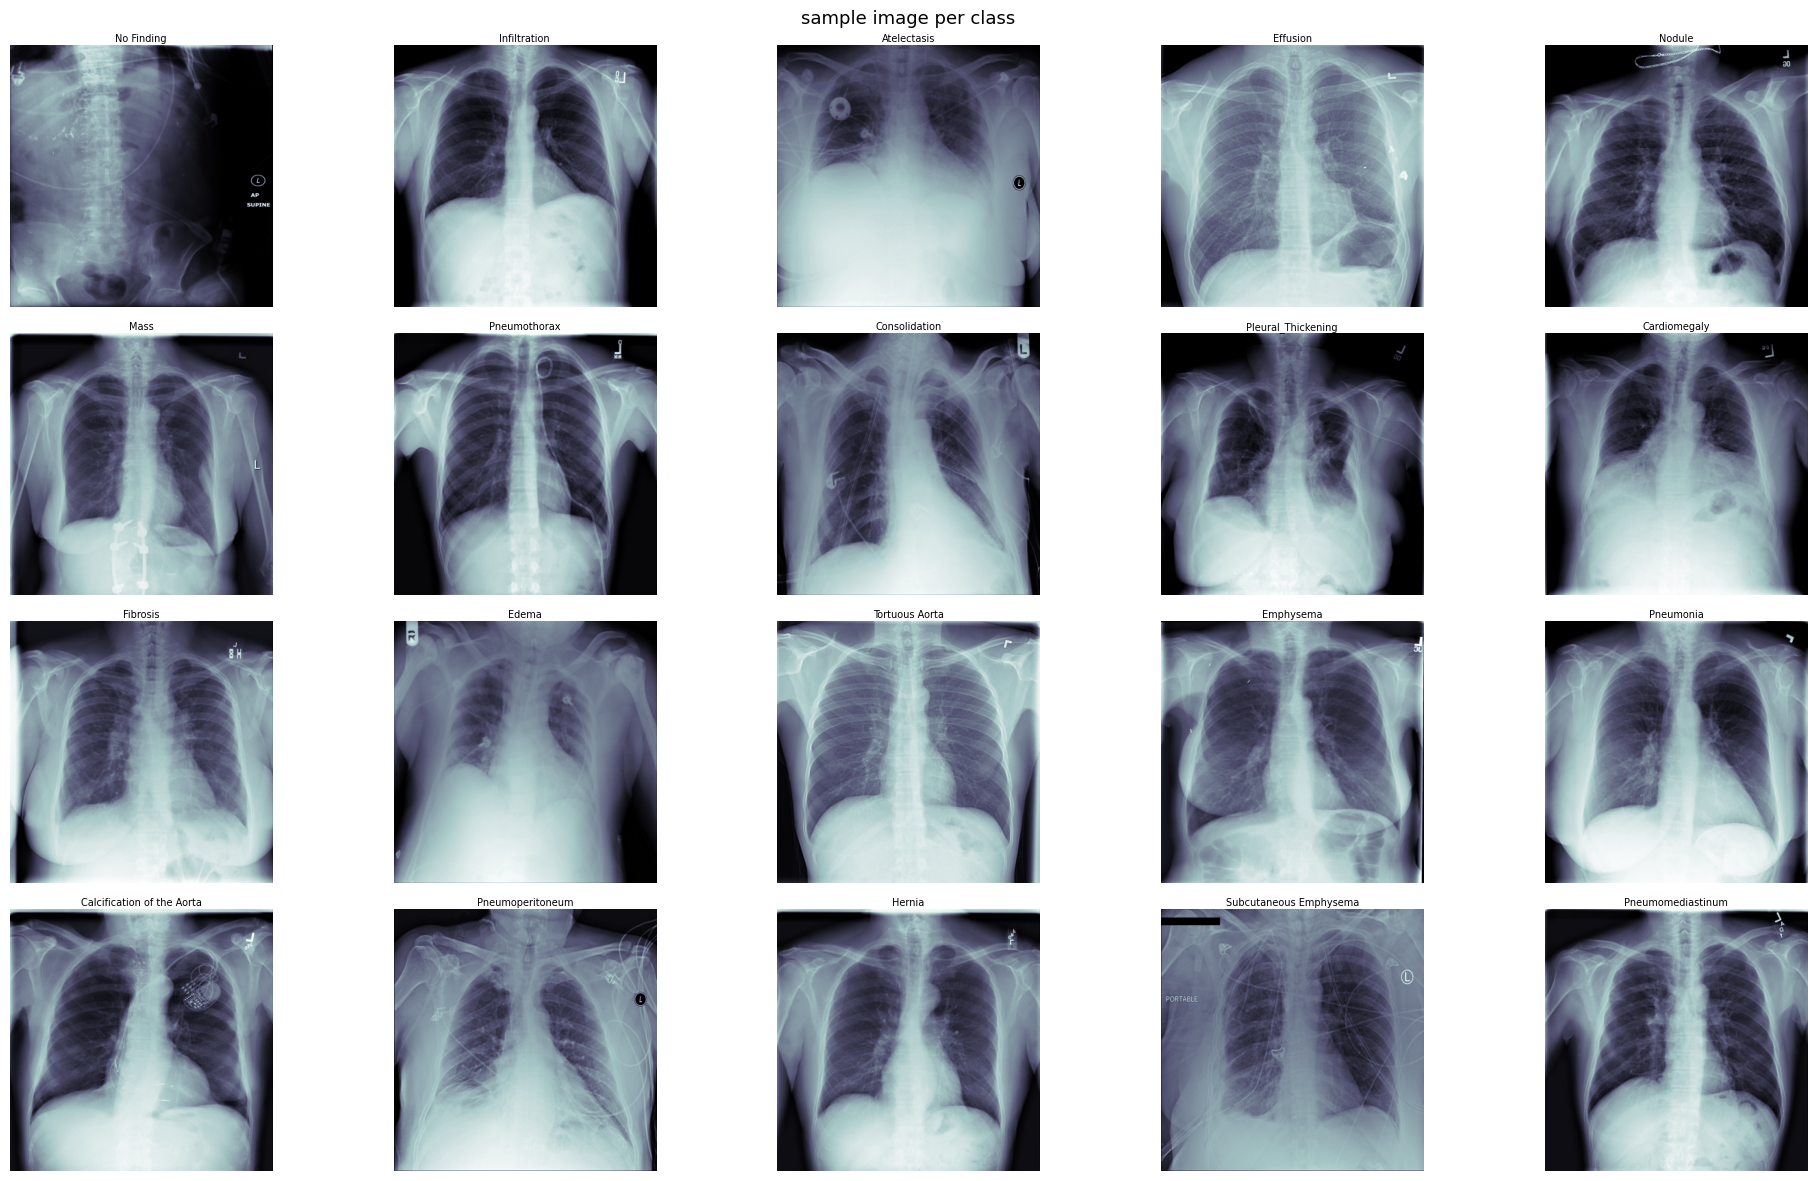

In [5]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(4, 5, figure=fig)

for idx, (name, _) in enumerate(class_cnts[:20]):
    cls_idx = CLASS_NAMES.index(name)
    row_df  = train_df[train_df["_label"] == cls_idx]
    if len(row_df) == 0:
        continue
    img_path = CFG.img_dir / row_df.iloc[0]["id"]
    if not img_path.exists():
        continue
    img = Image.open(img_path).convert("L")
    ax  = fig.add_subplot(gs[idx // 5, idx % 5])
    ax.imshow(img, cmap="bone")
    ax.set_title(name, fontsize=7, pad=2)
    ax.axis("off")

plt.suptitle("sample image per class", fontsize=13)
plt.tight_layout()
plt.savefig(CFG.output_dir / "sample_images.png", dpi=80)
plt.show()

In [6]:
sample_ids = train_df["id"].sample(min(100, len(train_df)), random_state=CFG.seed)
resolutions = []
for sid in sample_ids:
    p = CFG.img_dir / sid
    if p.exists():
        w, h = Image.open(p).size
        resolutions.append((w, h))

ws, hs = zip(*resolutions)
print(f"width  - min {min(ws)}, max {max(ws)}, mean {np.mean(ws):.0f}")
print(f"height - min {min(hs)}, max {max(hs)}, mean {np.mean(hs):.0f}")

unique_res = Counter(resolutions)
print(f"\nunique resolutions: {len(unique_res)}")
for res, cnt in unique_res.most_common(5):
    print(f"  {res} -> {cnt} images")

width  - min 384, max 384, mean 384
height - min 384, max 384, mean 384

unique resolutions: 1
  (384, 384) -> 100 images


In [7]:
class XRayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["id"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, row["id"]
        label = int(row[CLASS_NAMES].values.astype(int).argmax())
        return img, torch.tensor(label, dtype=torch.long)

def get_transforms(mode="train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if mode == "train":
        return transforms.Compose([
            transforms.Resize((CFG.img_size, CFG.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
        ])
    elif mode == "tta":
        return transforms.Compose([
            transforms.Resize((CFG.img_size, CFG.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((CFG.img_size, CFG.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

print("dataset and transforms ready")

dataset and transforms ready


In [8]:
def get_class_weights(df):
    labels  = df[CLASS_NAMES].values.argmax(axis=1)
    counts  = Counter(labels)
    total   = sum(counts.values())
    weights = torch.zeros(CFG.num_classes)
    for cls, cnt in counts.items():
        weights[cls] = total / (CFG.num_classes * cnt)
    return weights


def get_sampler(df):
    labels   = df[CLASS_NAMES].values.argmax(axis=1)
    class_w  = get_class_weights(df)
    sample_w = [class_w[l].item() for l in labels]
    return WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)


# ===== SPLIT LOGIC (FIXED) =====
skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
splits = list(skf.split(train_df, train_df["_label"]))

print(f"Total folds: {CFG.n_folds}  |  Training fold: {CFG.train_fold}")

train_idx, val_idx = splits[CFG.train_fold]

fold_train = train_df.iloc[train_idx].reset_index(drop=True)
fold_val   = train_df.iloc[val_idx].reset_index(drop=True)

print(f"  fold {CFG.train_fold}:  train {len(fold_train):>6}  |  val {len(fold_val):>5}")

Total folds: 5  |  Training fold: 0
  fold 0:  train  40834  |  val 10209


In [9]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):
        logits = logits.float()
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        return focal.mean()

print("focal loss defined")

focal loss defined


In [10]:
class XRayModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(CFG.model_name, pretrained=True, num_classes=0)
        in_feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_feat, 512),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, CFG.num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("XRayModel defined")
model = XRayModel().to(CFG.device)
print(f"model loaded on {CFG.device}")
print(f"backbone output features: {model.backbone.num_features}")

XRayModel defined


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model loaded on cuda
backbone output features: 1536


In [11]:
def competition_score(y_true, y_pred):
    scores = []
    for c in range(CFG.num_classes):
        mask_true = (y_true == c)
        N_c = mask_true.sum()
        if N_c == 0:
            continue
        mask_pred = (y_pred == c)
        TP = ( mask_true &  mask_pred).sum()
        FP = (~mask_true &  mask_pred).sum()
        FN = ( mask_true & ~mask_pred).sum()
        scores.append((CFG.w_tp*TP + CFG.w_fp*FP + CFG.w_fn*FN) / N_c)
    return float(np.mean(scores))

def compute_accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

print("metric functions ready")

metric functions ready


In [12]:
train_loader = DataLoader(
    XRayDataset(fold_train, CFG.img_dir, get_transforms("train")),
    batch_size=CFG.batch_size,
    sampler=get_sampler(fold_train),
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    XRayDataset(fold_val, CFG.img_dir, get_transforms("val")),
    batch_size=CFG.batch_size * 2,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
)

cw_device = get_class_weights(fold_train).to(CFG.device)
criterion = FocalLoss(weight=cw_device, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs, eta_min=1e-6)

print("dataloaders and optimizer ready")
print(f"train batches per epoch: {len(train_loader)}")
print(f"val batches per epoch: {len(val_loader)}")

dataloaders and optimizer ready
train batches per epoch: 1276
val batches per epoch: 160


In [13]:
fold = CFG.train_fold

print(f"\n{'='*70}")
print(f"  FOLD {fold}")
print(f"{'='*70}")

best_val_score = -999.0
ckpt_path = CFG.output_dir / f"best_model_fold{fold}.pt"
history = {
    "tr_loss": [],
    "vl_loss": [],
    "tr_score": [],
    "vl_score": [],
    "tr_acc": [],
    "vl_acc": []
}

scaler = torch.cuda.amp.GradScaler()

print(f"\n  {'ep':>3}  {'tr_loss':>8}  {'tr_score':>9}  {'tr_acc':>7}  {'vl_loss':>8}  {'vl_score':>9}  {'vl_acc':>7}")

for epoch in range(1, CFG.epochs + 1):
    model.train()
    total_loss, all_labels, all_preds = 0.0, [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(CFG.device), labels.to(CFG.device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(logits.argmax(1).cpu().numpy())

    tr_loss = total_loss / len(train_loader)
    tr_score = competition_score(np.array(all_labels), np.array(all_preds))
    tr_acc = compute_accuracy(np.array(all_labels), np.array(all_preds))

    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(CFG.device), labels.to(CFG.device)

            with torch.cuda.amp.autocast():
                logits = model(imgs)

            total_loss += criterion(logits, labels).item()
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(F.softmax(logits, dim=1).cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)

    vl_loss = total_loss / len(val_loader)
    vl_score = competition_score(all_labels, all_probs.argmax(axis=1))
    vl_acc = compute_accuracy(all_labels, all_probs.argmax(axis=1))

    scheduler.step()

    history["tr_loss"].append(tr_loss)
    history["vl_loss"].append(vl_loss)
    history["tr_score"].append(tr_score)
    history["vl_score"].append(vl_score)
    history["tr_acc"].append(tr_acc)
    history["vl_acc"].append(vl_acc)

    saved = ""
    if vl_score > best_val_score:
        best_val_score = vl_score
        torch.save({
            "epoch": epoch,
            "fold": fold,
            "model_state": model.state_dict(),
            "val_score": vl_score,
            "val_probs": all_probs,
            "val_labels": all_labels,
        }, ckpt_path)
        saved = "  ✓ saved"

    print(f"{epoch:>3}  {tr_loss:>8.4f}  {tr_score:>9.4f}  {tr_acc:>7.3f}  {vl_loss:>8.4f}  {vl_score:>9.4f}  {vl_acc:>7.3f}{saved}")

print(f"\nbest val score: {best_val_score:.4f}")


  FOLD 0

   ep   tr_loss   tr_score   tr_acc   vl_loss   vl_score   vl_acc
  1   11.4594    -3.3691    0.376    3.1586   -15.7859    0.028  ✓ saved
  2    3.0753    -1.9876    0.572    3.8428   -11.0293    0.043  ✓ saved
  3    1.9532    -1.4749    0.649    4.0914    -9.0885    0.056  ✓ saved
  4    1.1330    -1.0141    0.711    4.4920    -8.0362    0.072  ✓ saved
  5    0.7521    -0.7060    0.756    4.5248    -8.7430    0.072
  6    0.5351    -0.4933    0.785    5.4282    -7.4011    0.081  ✓ saved
  7    0.3801    -0.3049    0.814    5.6822    -6.7025    0.086  ✓ saved
  8    0.3242    -0.1451    0.838    5.8347    -6.7744    0.087
  9    0.2230    -0.0794    0.846    5.9179    -6.2712    0.098  ✓ saved
 10    0.1851    -0.0269    0.852    6.0324    -6.3032    0.097

best val score: -6.2712


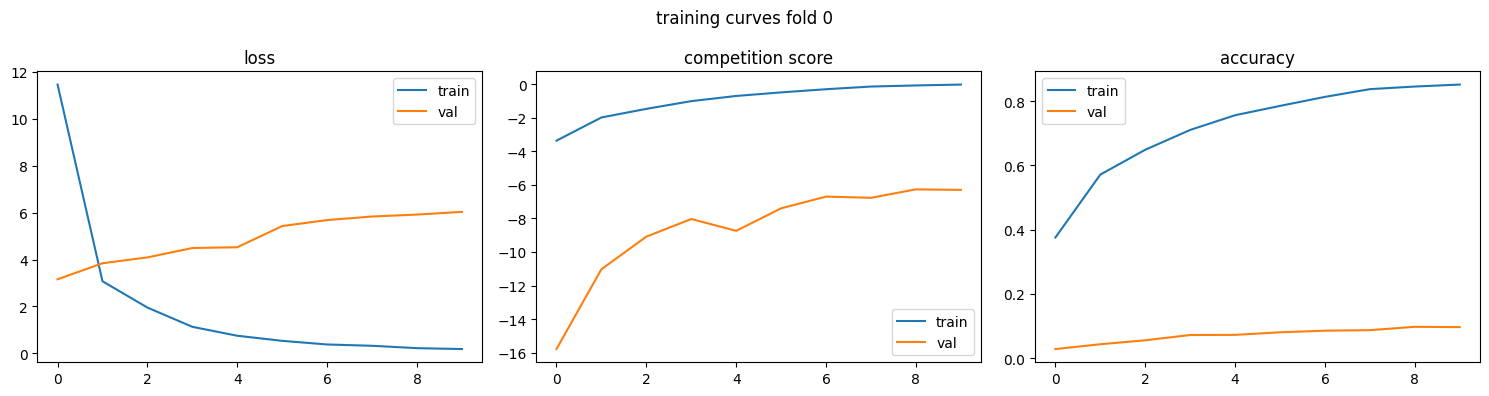

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["tr_loss"], label="train")
axes[0].plot(history["vl_loss"], label="val")
axes[0].set_title("loss")
axes[0].legend()

axes[1].plot(history["tr_score"], label="train")
axes[1].plot(history["vl_score"], label="val")
axes[1].set_title("competition score")
axes[1].legend()

axes[2].plot(history["tr_acc"], label="train")
axes[2].plot(history["vl_acc"], label="val")
axes[2].set_title("accuracy")
axes[2].legend()

plt.suptitle(f"training curves fold {fold}")
plt.tight_layout()
plt.savefig(CFG.output_dir / f"curves_fold{fold}.png", dpi=80)
plt.show()

In [15]:
ckpt = torch.load(ckpt_path, weights_only=False)
val_probs = ckpt["val_probs"]
val_labels = ckpt["val_labels"]

log_probs = np.log(val_probs + 1e-8)
best_bias = 0.0
best_score = -999.0

for bias in np.arange(-2.0, 6.0, 0.05):
    adj = log_probs.copy()
    adj[:, NO_FINDING_IDX] -= bias
    score = competition_score(val_labels, adj.argmax(axis=1))
    if score > best_score:
        best_score = score
        best_bias = bias

print(f"best no-finding bias: {best_bias:.2f}")
print(f"calibrated val score: {best_score:.4f}")

best no-finding bias: -2.00
calibrated val score: -6.2694


In [16]:
model.load_state_dict(torch.load(ckpt_path, weights_only=False)["model_state"])
model.eval()

avg_probs = None
tta_rounds = 2

for t in range(tta_rounds):
    mode = "val" if t == 0 else "tta"
    ds = XRayDataset(test_df, CFG.img_dir, get_transforms(mode), is_test=True)
    dl = DataLoader(ds, batch_size=CFG.batch_size * 2, shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

    round_probs = []
    with torch.no_grad():
        for imgs, _ in dl:
            with torch.cuda.amp.autocast():
                logits = model(imgs.to(CFG.device))
                probs = F.softmax(logits, dim=1)
            round_probs.append(probs.cpu().numpy())

    round_probs = np.concatenate(round_probs, axis=0)
    avg_probs = round_probs if avg_probs is None else avg_probs + round_probs
    print(f"tta pass {t+1}/{tta_rounds} done")

test_probs = avg_probs / tta_rounds
print(f"test probs shape: {test_probs.shape}")

tta pass 1/2 done
tta pass 2/2 done
test probs shape: (17015, 20)


In [17]:
test_log_probs = np.log(test_probs + 1e-8)
test_log_probs[:, NO_FINDING_IDX] -= best_bias
test_preds = test_log_probs.argmax(axis=1)

sub = pd.DataFrame({"id": test_df["id"].values})
for i, cls in enumerate(CLASS_NAMES):
    sub[cls] = (test_preds == i).astype(int)

assert (sub[CLASS_NAMES].sum(axis=1) == 1).all(), "some rows dont have exactly one 1"
sample_sub = pd.read_csv(CFG.sub_csv)
assert list(sample_sub.columns) == list(sub.columns), "column order mismatch"
assert len(sub) == len(test_df), "row count mismatch"

sub.to_csv(CFG.output_dir / "submission.csv", index=False)

print(f"submission saved — {len(sub):,} rows")
print(f"\nconfig summary:")
print(f"  model          : {CFG.model_name}")
print(f"  fold           : {fold}")
print(f"  TTA rounds     : {tta_rounds}")
print(f"  No-Finding bias: {best_bias:.2f}")
print(f"  calibrated val : {best_score:.4f}")

print(f"\nprediction distribution:")
for ci, cnt in sorted(Counter(test_preds).items(), key=lambda x: -x[1]):
    print(f"  {CLASS_NAMES[ci]:<35} {cnt:>6}  ({cnt/len(test_preds)*100:.1f}%)")

sub.head()

submission saved — 17,015 rows

config summary:
  model          : efficientnet_b3
  fold           : 0
  TTA rounds     : 2
  No-Finding bias: -2.00
  calibrated val : -6.2694

prediction distribution:
  Nodule                                5446  (32.0%)
  Atelectasis                           2919  (17.2%)
  Effusion                              1744  (10.2%)
  Pneumothorax                          1273  (7.5%)
  Mass                                  1249  (7.3%)
  Cardiomegaly                           853  (5.0%)
  Infiltration                           719  (4.2%)
  Pleural_Thickening                     673  (4.0%)
  Consolidation                          562  (3.3%)
  Edema                                  443  (2.6%)
  Tortuous Aorta                         366  (2.2%)
  Fibrosis                               289  (1.7%)
  Emphysema                              172  (1.0%)
  Pneumonia                              164  (1.0%)
  Calcification of the Aorta              93  (0.5%)

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
